**VAE : Variational Auto Encoder**
A generative model that consistes of an Encoder ( which compress the input)
and a decoder (which reconstructs or decompress the input from the compressed data)

In [ ]:
import torch # import pytorch library
import torch.nn as nn # for building layers in the neural nw
import torch.optim as optim # for optimization algos
import torchvision # pytorch computer vision library for img data
import torchvision.transforms as transforms # image transformations
from torch.utils.data import DataLoader # load data in batches
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from torch.nn.modules.activation import ReLU
#define a class for our VAE extending the neural network module class of pytorch
class VAE(nn.Module):
  def __init__(self, input_dim = 784, hidden_dim= 400, latent_dim = 20):
    # initialize the VAE parameters
    # input_dim  : no. of input features (28x28 = 784 for mnist)
    # hidden_dim : no. of nodes in hidden layer (half of ip)
    # latent_dim : no. of dimension in latent space (compressed)

    #call the constructor of the parent class
    super(VAE, self).__init__()


    #ENCODER
    ############
    #create an encoder converts ip into latent dims
    #create an encoder layer object of Sequential class
    self.encoder = nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        #first fully connected layer with Linear activation
        nn.ReLU() # relu activation
    )

    #create a seperate layer for learning mean
    self.mu_layer = nn.Linear(hidden_dim, latent_dim)
    #create another seperate layer for learning variance
    self.log_var_layer = nn.Linear(hidden_dim, latent_dim)


    #DECODER NETWORK
    ################
    #create an decoder converts latent dims into output
    self.decoder = nn.Sequential(
        nn.Linear(latent_dim, hidden_dim),
        #first fully connected layer with Linear activation
        nn.ReLU(), # relu activation
        nn.Linear(hidden_dim, input_dim),
        #to make sure the output values are between zero and one
        #use a sigmoid activation fn
        nn.Sigmoid()
    )

  #within the class define the fn for reparametrization
  def reparameterize(self,my, log_var):
    #randomness z = mean +std * random noise epsilon
    std = torch.exp(0.5*log_var)
    epsilotn = torch.randn_like(std)
    return my + std*epsilotn

  #fn for forward pass of the neural network(both enc and dec)
  def forward(self,x):
    x = self.encoder(x) #encode the input data
    mu = self.mu_layer(x) #compute mean
    log_var = self.log_var_layer(x) #compute log variance
    z = self.reparameterize(mu,log_var)
    reconstructed_x = self.decoder(z) #decode it back to image
    return reconstructed_x, mu, log_var

In [ ]:
#define the loss fn and do the losss calculation
# VAE loss fn consist of two types of loss calculation
# 1. Reconstruction loss : checking if output is similar to input
# 2. KL Divergence loss : Ensure the learned latent space is following a normal distribution

def loss_fn(reconstructed_x, x, mu, log_var):
  #calculate the reconstruction loss
  recon_loss = nn.functional.binary_cross_entropy(reconstructed_x,x,reduction='sum')
  kl_loss = -0.5 * torch.sum(1+log_var-mu.pow(2)-log_var.exp())
  #return total loss
  return recon_loss + kl_loss

In [ ]:
#Load the mnist dataset
# step 1 : transform the 28 * 28 images into an 1D vector
#create a transform object for that
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x : x.view(-1))
    #flatten the image to an 1D image
])

# step 2 : Load the dataset
train_dataset = torchvision.datasets.MNIST(root = './data',
                                           train = True,
                                           transform = transform, download = True )
# to load the data in batches, use the DataLoader class obj
train_loader = DataLoader(train_dataset, batch_size = 64,
                          shuffle = True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 141MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 50.9MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 141MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.80MB/s]


In [ ]:
#Train the VAE
#Step 1 : initialize the model, optimizer and device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE().to(device) #load the model class to device
optimizer = optim.Adam(model.parameters(), lr = 1e-3)

In [ ]:
#step 2 : Define the Training Loop
num_epochs = 10
for epoch in range(num_epochs):
  total_loss = 0
  for batch_idx, (x, _) in enumerate (train_loader):
    #move data to the device
    x = x.to(device)
    #using the model, reconstruct/generate the image
    reconstructed_x, mu, log_var = model(x)

    #calculate the loss using the available details
    loss = loss_fn(reconstructed_x, x, mu, log_var)

    #Back Propagation
    #reset the gradients of the optimizer
    optimizer.zero_grad()

    #compute the gradients
    loss.backward()

    #update tmodel params using optimizer
    optimizer.step()

    #calculate total loss
    total_loss = loss.item()
  #for each epoch point from torch.nn.modules.activation import ReLU
  print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(train_loader)}")

Epoch 1/10, Loss: 3.9788956306636463
Epoch 2/10, Loss: 3.735879926539179
Epoch 3/10, Loss: 3.57808049248734
Epoch 4/10, Loss: 3.733636071178705
Epoch 5/10, Loss: 3.8518134078491473
Epoch 6/10, Loss: 3.5846407957422706
Epoch 7/10, Loss: 3.440109025186567
Epoch 8/10, Loss: 3.586696470215885
Epoch 9/10, Loss: 3.511874916711087
Epoch 10/10, Loss: 3.5502966126399254


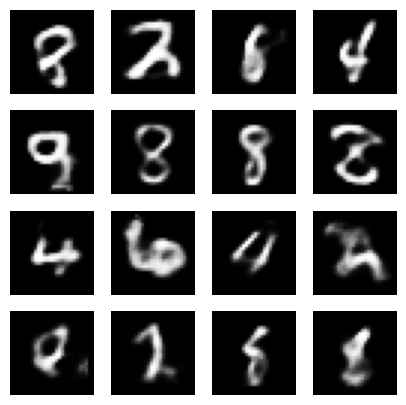

In [ ]:
#generate a set of images using our trained model
import matplotlib.pyplot as plt
with torch.no_grad():
  #create a blank random points in latent space
  z = torch.randn(16, 20 ).to(device)
  #using this blank latent space as input, our model should generate images
  generated_images = model.decoder(z).cpu() #decode our random z

#plot the generated 16 images in a 4x4 grid
fig, axis = plt.subplots(4, 4, figsize = (5,5))
#show the images as a loop
for i, ax in enumerate(axis.flatten()):
  ax.imshow(generated_images[i].view(28,28), cmap = 'gray')
  ax.axis('off')
#show the drawn plot
plt.show()

In [19]:
!git

data  VAE.ipynb


In [18]:
from google.colab import userdata
github_token = userdata.get('GITHUB_TOKEN')
!git remote set-url origin https://{github_token}@github.com/roshinsthomas/Variational-Autoencoder-MNIST.git
!git push -u origin main

branch 'main' set up to track 'origin/main'.
Everything up-to-date
